# Import Required Libraries

In [ ]:
# Необходимые импорты
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple
import random

In [ ]:
# Задание 1, 2, 3, 4. Реализация слоев
class BatchNorm:
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        self.gamma = torch.ones(num_features)
        self.beta = torch.zeros(num_features)
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)
        self.training = True

    def forward(self, x):
        if self.training:
            mean = x.mean(dim=0)
            var = x.var(dim=0, unbiased=False)
            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * mean
            self.running_var = self.momentum * self.running_var + (1 - self.momentum) * var
        else:
            mean = self.running_mean
            var = self.running_var
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta

class Linear:
    def __init__(self, in_features, out_features):
        self.in_features = in_features
        self.out_features = out_features
        self.weight = torch.randn(out_features, in_features) * 0.01
        self.bias = torch.zeros(out_features)

    def forward(self, x):
        return x @ self.weight.t() + self.bias

class Dropout:
    def __init__(self, p=0.5):
        self.p = p
        self.training = True

    def forward(self, x):
        if self.training:
            mask = torch.rand_like(x) > self.p
            return x * mask / (1 - self.p)
        return x

class ReLU:
    def forward(self, x):
        return torch.relu(x)

class Sigmoid:
    def forward(self, x):
        return torch.sigmoid(x)

class Softmax:
    def __init__(self, dim=-1):
        self.dim = dim

    def forward(self, x):
        return torch.softmax(x, dim=self.dim)

In [ ]:
# Задание 5, реализация фреймворка
class TensorNode:
    def __init__(self, data: torch.Tensor, _children: Tuple['TensorNode', ...] = (), _op: str = ''):
        self.data = data.clone().detach().requires_grad_(True)
        self.grad = torch.zeros_like(data)
        self._backward: callable = lambda: None
        self._prev: set = set(_children)
        self._op = _op

    def __repr__(self) -> str:
        return f"TensorNode(data={self.data.shape}, grad={self.grad.shape})"

    @staticmethod
    def _as_node(x):
        return x if isinstance(x, TensorNode) else TensorNode(x)

    def __add__(self, other):
        other = TensorNode._as_node(other)
        out = TensorNode(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = TensorNode._as_node(other)
        out = TensorNode(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out

    def relu(self):
        out = TensorNode(torch.relu(self.data), (self,), 'relu')
        def _backward():
            self.grad += out.grad * (self.data > 0).float()
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = torch.ones_like(self.data)
        for node in reversed(topo):
            node._backward()

In [ ]:
# Задание 2. Медианный фильтр
def median_filter(image, kernel_size):
    # image: torch.Tensor (C, H, W)
    # kernel_size: int, odd
    pad = kernel_size // 2
    padded = F.pad(image, (pad, pad, pad, pad), mode='reflect')
    unfolded = padded.unfold(1, kernel_size, 1).unfold(2, kernel_size, 1)
    # shape: (C, H, W, k, k)
    unfolded = unfolded.contiguous().view(image.shape[0], image.shape[1], image.shape[2], -1)
    # sort along last dim
    sorted_vals, _ = torch.sort(unfolded, dim=-1)
    median_idx = kernel_size * kernel_size // 2
    return sorted_vals[..., median_idx]

# Example
img = torch.rand(3, 10, 10)
for ks in [3, 5, 7]:  # 7 instead of 10 for simplicity
    filtered = median_filter(img, ks)
    print(f'Kernel {ks}: {filtered.shape}')

Kernel 3: torch.Size([3, 10, 10])
Kernel 5: torch.Size([3, 10, 10])
Kernel 7: torch.Size([3, 10, 10])


In [ ]:
# Задание 3. Трансформации
class BaseTransform:
    def __init__(self, p=1.0):
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            return self.apply(img)
        return img

    def apply(self, img):
        raise NotImplementedError

class RandomCrop(BaseTransform):
    def __init__(self, p=1.0, size=(224, 224), padding=0):
        super().__init__(p)
        self.size = size
        self.padding = padding

    def apply(self, img):
        if self.padding > 0:
            img = Image.new(img.mode, (img.size[0] + 2*self.padding, img.size[1] + 2*self.padding), (0,)*len(img.mode))
            img.paste(img, (self.padding, self.padding))
        w, h = img.size
        tw, th = self.size
        if w < tw or h < th:
            return img.resize((tw, th))
        x = random.randint(0, w - tw)
        y = random.randint(0, h - th)
        return img.crop((x, y, x + tw, y + th))

class RandomRotate(BaseTransform):
    def __init__(self, p=1.0, degrees=30):
        super().__init__(p)
        self.degrees = degrees

    def apply(self, img):
        angle = random.uniform(-self.degrees, self.degrees)
        return img.rotate(angle)

class RandomZoom(BaseTransform):
    def __init__(self, p=1.0, scale=(0.8, 1.2)):
        super().__init__(p)
        self.scale = scale

    def apply(self, img):
        zoom = random.uniform(*self.scale)
        w, h = img.size
        nw, nh = int(w * zoom), int(h * zoom)
        img = img.resize((nw, nh))
        # crop to original size
        x = (nw - w) // 2
        y = (nh - h) // 2
        return img.crop((x, y, x + w, y + h))

class ToTensor(BaseTransform):
    def __init__(self):
        super().__init__(1.0)  # always apply

    def apply(self, img):
        img = np.array(img) / 255.0
        if img.ndim == 2:  # grayscale
            img = img[None, ...]  # add channel dim (1, H, W)
        else:
            img = img.transpose(2, 0, 1)  # (C, H, W)
        return torch.from_numpy(img).float()

class Compose:
    def __init__(self, transforms: List[BaseTransform]):
        self.transforms = transforms

    def __call__(self, img):
        for t in self.transforms:
            img = t(img)
        return img

In [ ]:
# Задание 4. Подготовка данных
import torchvision
import torchvision.transforms as tv_transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# Assume FashionMNIST as in practice 2.2
transform_no_aug = ToTensor()

transform_aug = Compose([
    RandomCrop(p=1.0, size=(28, 28), padding=4),
    RandomRotate(p=1.0, degrees=10),
    ToTensor()
])

# For dataset, we need to apply transforms manually since torchvision uses its own
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

trainset_no_aug = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=None)
trainset_aug = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=None)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=None)

trainset_no_aug = CustomDataset(trainset_no_aug, transform_no_aug)
trainset_aug = CustomDataset(trainset_aug, transform_aug)
testset = CustomDataset(testset, transform_no_aug)

trainloader_no_aug = DataLoader(trainset_no_aug, batch_size=64, shuffle=True)
trainloader_aug = DataLoader(trainset_aug, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:15<00:00, 1.71MB/s]

100%|██████████| 29.5k/29.5k [00:00<00:00, 510kB/s]

100%|██████████| 4.42M/4.42M [00:02<00:00, 1.78MB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.50MB/s]



In [ ]:
# Задание 4. Определение модели
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)  # 1 channel for FashionMNIST
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(64*5*5, 128)  # Adjusted for 28x28 input
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(-1, 64*5*5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
# Задание 4. Обучение модели
def train_model(trainloader, testloader, epochs=10):
    model = SimpleCNN()
    optimizer = optim.Adam(model.parameters())
    criterion = nn.CrossEntropyLoss()
    train_losses, test_losses, test_accs = [], [], []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for x, y in trainloader:
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(trainloader))
        
        model.eval()
        test_loss = 0
        correct = 0
        with torch.no_grad():
            for x, y in testloader:
                out = model(x)
                loss = criterion(out, y)
                test_loss += loss.item()
                correct += (out.argmax(1) == y).sum().item()
        test_losses.append(test_loss / len(testloader))
        test_accs.append(correct / len(testset))
        print(f'Epoch {epoch+1}: Train Loss {train_losses[-1]:.4f}, Test Loss {test_losses[-1]:.4f}, Test Acc {test_accs[-1]:.4f}')
    return train_losses, test_losses, test_accs

# Train without aug
print("Training without augmentations:")
losses_no_aug, test_losses_no_aug, accs_no_aug = train_model(trainloader_no_aug, testloader)

# Train with aug
print("Training with augmentations:")
losses_aug, test_losses_aug, accs_aug = train_model(trainloader_aug, testloader)

Training without augmentations:
Epoch 1: Train Loss 0.5281, Test Loss 0.3780, Test Acc 0.8659
Epoch 1: Train Loss 0.5281, Test Loss 0.3780, Test Acc 0.8659
Epoch 2: Train Loss 0.3369, Test Loss 0.3440, Test Acc 0.8768
Epoch 2: Train Loss 0.3369, Test Loss 0.3440, Test Acc 0.8768
Epoch 3: Train Loss 0.2856, Test Loss 0.3059, Test Acc 0.8914
Epoch 3: Train Loss 0.2856, Test Loss 0.3059, Test Acc 0.8914
Epoch 4: Train Loss 0.2550, Test Loss 0.2857, Test Acc 0.8947
Epoch 4: Train Loss 0.2550, Test Loss 0.2857, Test Acc 0.8947
Epoch 5: Train Loss 0.2292, Test Loss 0.2591, Test Acc 0.9046
Epoch 5: Train Loss 0.2292, Test Loss 0.2591, Test Acc 0.9046
Epoch 6: Train Loss 0.2095, Test Loss 0.2619, Test Acc 0.9035
Epoch 6: Train Loss 0.2095, Test Loss 0.2619, Test Acc 0.9035
Epoch 7: Train Loss 0.1906, Test Loss 0.2439, Test Acc 0.9109
Epoch 7: Train Loss 0.1906, Test Loss 0.2439, Test Acc 0.9109
Epoch 8: Train Loss 0.1756, Test Loss 0.2486, Test Acc 0.9119
Epoch 8: Train Loss 0.1756, Test Loss 

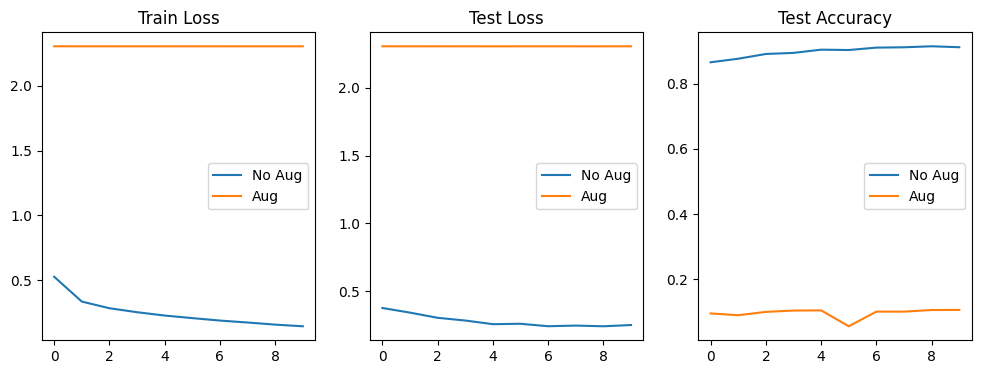

In [ ]:
# Задание 4. Визуализация результатов
# Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(losses_no_aug, label='No Aug')
plt.plot(losses_aug, label='Aug')
plt.title('Train Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(test_losses_no_aug, label='No Aug')
plt.plot(test_losses_aug, label='Aug')
plt.title('Test Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(accs_no_aug, label='No Aug')
plt.plot(accs_aug, label='Aug')
plt.title('Test Accuracy')
plt.legend()
plt.show()